In [29]:
import requests
import json
import pandas as pd
import psycopg2
import _utils_ as utils
import _connection_ as con

Variables

In [ ]:
city = 'Bogota'
gbfs_url='https://bogota.publicbikesystem.net/customer/gbfs/v2/gbfs.json'

In [17]:
all_data_links = requests.get(gbfs_url).json()
feeds_dict = {feed['name']: feed['url'] for feed in all_data_links['data']['en']['feeds']}
all_data_links

{'last_updated': 1748874284,
 'ttl': 30,
 'data': {'en': {'feeds': [{'name': 'geofencing_zones',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/geofencing_zones'},
    {'name': 'vehicle_types',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/vehicle_types'},
    {'name': 'station_information',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/station_information'},
    {'name': 'station_status',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/station_status'},
    {'name': 'system_regions',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/system_regions'},
    {'name': 'system_information',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/system_information'},
    {'name': 'system_pricing_plans',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/system_pricing_plans'},
    {'name': 'gbfs_versions',
     'url': 'https://bogota.publicbikesystem.net

## 1 - Exploracion de Datos

### 1.1 Informacion general del sistema

In [18]:
geofencing_zones  = requests.get(feeds_dict['geofencing_zones']).json()
system_regions  = requests.get(feeds_dict['system_regions']).json()
system_information  = requests.get(feeds_dict['system_information']).json()
gbfs_versions = requests.get(feeds_dict['gbfs_versions']).json()
print("geofencing_zones\n", geofencing_zones['data'])
print("\nsystem_regions\n", system_regions['data'])
print("\nsystem_information\n", system_information['data'])
print("\ngbfs_versions\n",  gbfs_versions['data'])

geofencing_zones
 {'geofencing_zones': {'features': [], 'type': 'FeatureCollection'}}

system_regions
 {'regions': []}

system_information
 {'system_id': 'bogota_bike', 'language': 'en', 'name': 'bogota-bikebogota', 'timezone': 'America/Bogota', 'build_version': '2025.1', 'build_label': '2025-05-20', 'build_hash': '6a49935', 'build_number': '48', 'mobile_head_version': '2', 'mobile_minimum_supported_version': '1', '_vehicle_count': {'_mechanical_count': 1952, '_ebike_count': 1556}, '_station_count': 288}

gbfs_versions
 {'versions': [{'version': '1.1', 'url': 'https://bogota.publicbikesystem.net/ube/gbfs/v1/'}, {'version': '2.3', 'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/'}]}


### 1.2. Precios de planes y tipos de vehiculos

In [6]:
# system_pricing_plans
system_pricing_plans = requests.get(feeds_dict['system_pricing_plans']).json()
for plan in system_pricing_plans['data']['plans'][0:5]:
    print(plan)


{'per_minute_pricing': [{'start': 0, 'rate': 7500.0, 'interval': 30, 'end': 30}], 'plan_id': '1', 'name': 'Teste 06.09', 'currency': 'COP', 'price': 9000.0, 'description': 'Teste 06.09', 'is_taxable': True}
{'per_minute_pricing': [{'start': 0, 'rate': 7500.0, 'interval': 30, 'end': 30}], 'plan_id': '1-1', 'name': 'Teste 06.09', 'currency': 'COP', 'price': 9000.0, 'description': 'Teste 06.09', 'is_taxable': True}
{'per_minute_pricing': [{'start': 0, 'rate': 7500.0, 'interval': 30, 'end': 30}], 'plan_id': '1-2', 'name': 'Teste 06.09', 'currency': 'COP', 'price': 9000.0, 'description': 'Teste 06.09', 'is_taxable': True}
{'per_minute_pricing': [{'start': 65, 'rate': 150.0, 'interval': 1, 'end': 2465}], 'plan_id': '2', 'name': 'Diario', 'currency': 'COP', 'price': 11000.0, 'description': 'Diario', 'is_taxable': True}
{'per_minute_pricing': [{'start': 65, 'rate': 150.0, 'interval': 1, 'end': 2465}], 'plan_id': '2-1', 'name': 'Diario', 'currency': 'COP', 'price': 11000.0, 'description': 'Diar

In [7]:
#vehicle_types
vehicle_types = requests.get(feeds_dict['vehicle_types']).json()
pd.DataFrame(vehicle_types['data']['vehicle_types'])

,vehicle_type_id,form_factor,propulsion_type,max_range_meters,name,default_pricing_plan_id
0,ICONIC,bicycle,human,0.0,ICONIC,1-1
1,FIT,bicycle,human,0.0,FIT,1-1
2,BOOST,bicycle,electric_assist,70000.0,BOOST,1-2
3,EFIT,bicycle,electric_assist,70000.0,EFIT,1-2
4,MANOCLETA,other,human,0.0,MANOCLETA,3-3
5,CAJON,bicycle,human,0.0,CAJON,3-3
6,FIT CON SILLA,bicycle,human,0.0,FIT CON SILLA,1-1
7,EFIT CON SILLA,bicycle,electric_assist,200000.0,EFIT CON SILLA,1-2
8,Handbike,bicycle,human,0.0,Handbike,3-3
9,CARGO,bicycle,human,0.0,CARGO,3-3


### 1.3 Informacion y Estado de Estacion

In [19]:
station_information = requests.get(feeds_dict['station_information']).json()
print("numero de estaciones: ", len(station_information['data']['stations']))
print(station_information['data']['stations'][0])
station_information_df = pd.DataFrame(station_information['data']['stations'][0:-1])
station_information_df[-4:-1]

numero de estaciones:  289
{'station_id': '1', 'name': '001 - CL 82 con KR 11', 'physical_configuration': 'REGULAR', 'lat': 4.6658027, 'lon': -74.0528436, 'altitude': None, 'address': 'Calle 82 entre Carrera 11 y Carrera 12', 'cross_street': 'EL RETIRO', 'post_code': '1111', 'capacity': 19, 'is_charging_station': False, 'geofenced_capacity': 0, 'rental_methods': ['KEY', 'TRANSITCARD', 'CREDITCARD', 'PHONE'], 'is_virtual_station': False, 'groups': [], 'nearby_distance': 1000.0, '_bluetooth_id': '1835', '_ride_code_support': True, 'rental_uris': {}}


,station_id,name,physical_configuration,lat,lon,altitude,address,cross_street,post_code,capacity,...,geofenced_capacity,rental_methods,is_virtual_station,groups,nearby_distance,_bluetooth_id,_ride_code_support,rental_uris,obcn,short_name
284,298,298 - KR 23 con CL 104A,REGULAR,4.691679,-74.055155,NaN,Carrera 23 entre Calle 104A y Calle 104,NaN,1111,14,...,0,"[KEY, TRANSITCARD, CREDITCARD, PHONE]",False,[],1000.0,499f,True,{},,
285,299,299 - CL 11 con KR 8,REGULAR,4.599279,-74.076978,NaN,Calle 11 entre Carrera 8 y Carrera 9,CENTRO ADMINISTRATIVO,1111,15,...,0,"[KEY, TRANSITCARD, CREDITCARD, PHONE]",False,[],1000.0,f751,True,{},,
286,300,300 - KR 18A con CL 102,REGULAR,4.687820,-74.050715,NaN,Carrera 18A entre Calle 102 y Calle 103,NaN,1111,23,...,0,"[KEY, TRANSITCARD, CREDITCARD, PHONE]",False,[],1000.0,ddf2,True,{},,


In [20]:
station_status= requests.get(feeds_dict['station_status']).json()
print("numero de estaciones: ", len(station_status['data']['stations']))
print(list(station_status['data']['stations'][0].keys()))
print('vehicle_docks_available',station_status['data']['stations'][0]['vehicle_docks_available'])

print('vehicle_types_available')
for veh_type in station_status['data']['stations'][0]['vehicle_types_available']:
    print("  ",veh_type)
station_status_df = pd.DataFrame(station_status['data']['stations'])
station_status_df[0:4]

# station_status

numero de estaciones:  289
['station_id', 'num_bikes_available', 'num_bikes_disabled', 'num_docks_available', 'num_docks_disabled', 'last_reported', 'is_charging_station', 'status', 'is_installed', 'is_renting', 'is_returning', 'traffic', 'vehicle_docks_available', 'vehicle_types_available']
vehicle_docks_available [{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO', 'Handbike'], 'count': 8}]
vehicle_types_available
   {'vehicle_type_id': 'FIT', 'count': 5}
   {'vehicle_type_id': 'CARGO', 'count': 0}
   {'vehicle_type_id': 'Handbike', 'count': 0}
   {'vehicle_type_id': 'EFIT', 'count': 0}


,station_id,num_bikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled,last_reported,is_charging_station,status,is_installed,is_renting,is_returning,traffic,vehicle_docks_available,vehicle_types_available
0,1,5,6,8,0,1748874273,False,IN_SERVICE,True,True,True,None,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 5}, {'veh..."
1,2,1,2,4,0,1748874266,False,IN_SERVICE,True,True,True,None,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 1}, {'veh..."
2,3,3,6,1,0,1748874221,False,IN_SERVICE,True,True,True,None,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 3}, {'veh..."
3,4,3,0,8,0,1748874355,False,IN_SERVICE,True,True,True,None,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 1}, {'veh..."


## 2 - Visualizacion de Informacion

<Figure size 800x800 with 0 Axes>

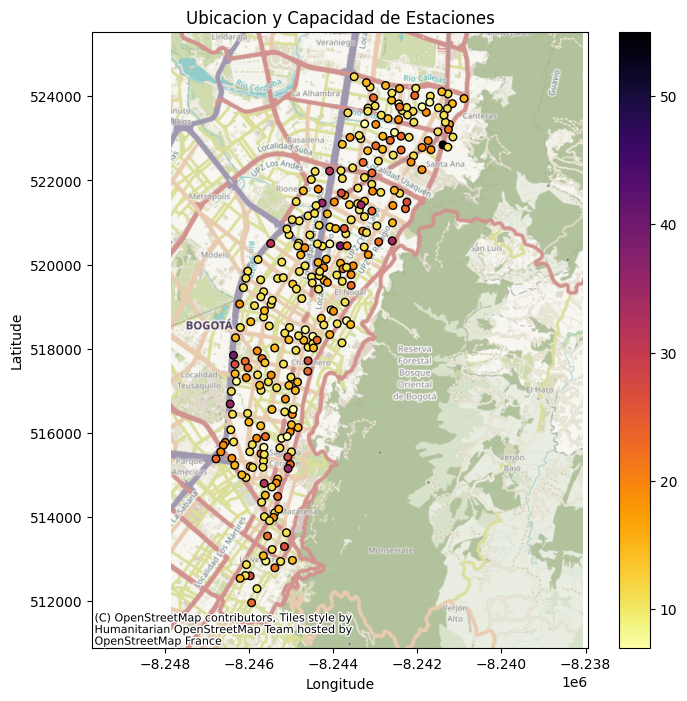

In [21]:
utils.plot_map(station_information_df, 'capacity', 'inferno_r', 'Ubicacion y Capacidad de Estaciones')

<Figure size 800x800 with 0 Axes>

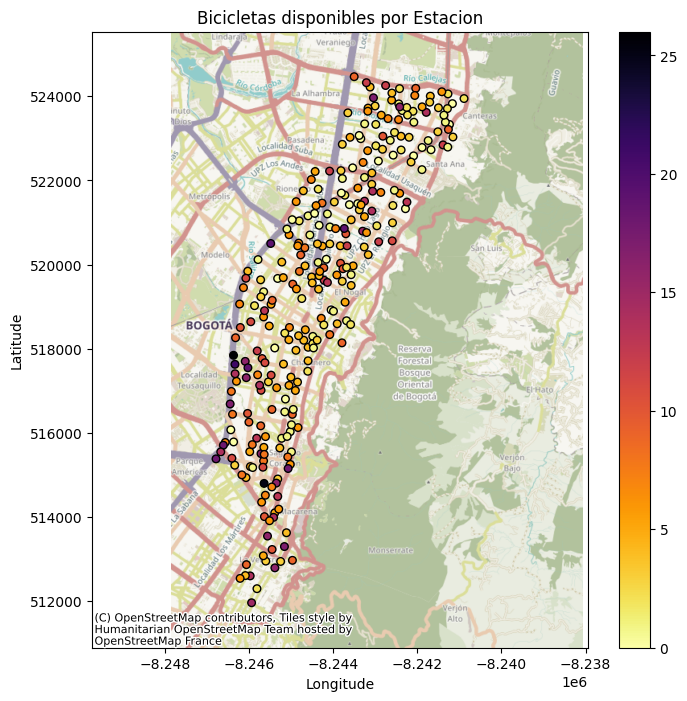

In [22]:
station_info_status_df = station_information_df.merge(station_status_df, on='station_id')
utils.plot_map(station_info_status_df, 'num_bikes_available', 'inferno_r', 'Bicicletas disponibles por Estacion')

<Figure size 800x800 with 0 Axes>

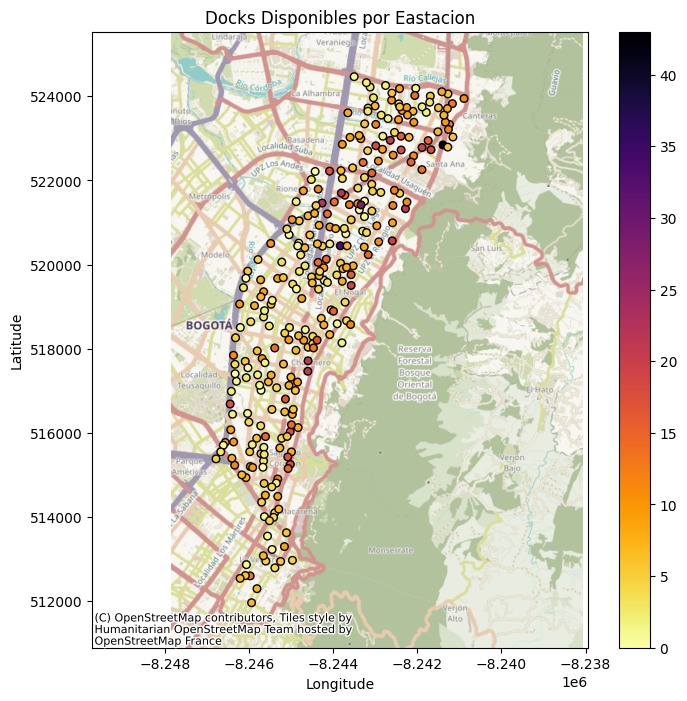

In [23]:
utils.plot_map(station_info_status_df, 'num_docks_available', 'inferno_r', 'Docks Disponibles por Eastacion')